# SDG 6: Clean Water and Sanitation Analysis
## Identifying Drivers of Water Access via Regression Analysis

In [43]:
# 1. DATA LOADING AND EXPLORATION
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df_raw = pd.read_csv('/content/washdash-download.csv')

print("Dataset Exploration:")
print(f"Initial Shape: {df_raw.shape}")
display(df_raw.head())
print("\nSummary Statistics:")
display(df_raw.describe())


Dataset Exploration:
Initial Shape: (266, 8)


,Type,Region,Residence Type,Service Type,Year,Coverage,Population,Service level
0,sdg,Australia and New Zealand,total,Sanitation,2024,5.36589,1.713175e+06,Basic service
1,sdg,Australia and New Zealand,total,Sanitation,2024,0.00000,0.000000e+00,Limited service
2,sdg,Australia and New Zealand,total,Sanitation,2024,0.00000,0.000000e+00,Open defecation
3,sdg,Australia and New Zealand,total,Sanitation,2024,94.63411,3.021397e+07,Safely managed service
4,sdg,Australia and New Zealand,total,Sanitation,2024,0.00000,0.000000e+00,Unimproved



Summary Statistics:


,Year,Coverage,Population
count,266.0,266.000000,2.660000e+02
mean,2024.0,23.165346,1.704059e+08
std,0.0,28.710158,3.344872e+08
min,2024.0,0.000000,0.000000e+00
25%,2024.0,1.887970,3.722965e+06
50%,2024.0,9.699400,2.784275e+07
75%,2024.0,34.766748,1.812776e+08
max,2024.0,100.000000,2.206959e+09


## 2. Data Cleaning Techniques
In this section, we employ filtering to isolate specific service levels ('Drinking water') and residence types ('total') to ensure a consistent unit of analysis. We also handle missing values in 'Coverage' and 'Population' columns.

In [44]:
# 2. DATA CLEANING
# Technique 1: Contextual Filtering
df = df_raw[
    (df_raw['Service Type'].str.contains('Water', case=False)) &
    (df_raw['Residence Type'] == 'total')
].copy()

# Technique 2: Handling Nulls and Renaming for clarity
df = df.dropna(subset=['Coverage', 'Population'])
df = df.rename(columns={'Coverage': 'water_access', 'Region': 'region', 'Population': 'population'})

# Adding a synthetic GDP variable for multivariate context
np.random.seed(42)
df['gdp_per_capita'] = np.random.normal(12000, 3000, len(df))

print(f"✅ Cleaning complete. {len(df)} records remaining.")
display(df[['region', 'water_access', 'population', 'gdp_per_capita']].head())

✅ Cleaning complete. 37 records remaining.


,region,water_access,population,gdp_per_capita
5,Australia and New Zealand,99.97459,3.191904e+07,13490.142459
8,Australia and New Zealand,0.00000,0.000000e+00,11585.207096
11,Australia and New Zealand,0.00000,0.000000e+00,13943.065614
15,Australia and New Zealand,0.02541,8.111207e+03,16569.089569
42,Central and Southern Asia,18.13557,3.892405e+08,11297.539876


## 3. Variable Definitions and Literature Review

**Response Variable:**
- **Water Access (water_access)**: The percentage of the population using safely managed drinking water services.

**Explanatory Variables:**
1. **Demographic Pressure (population)**: Rapid population growth can strain existing water infrastructure (UN-Water, 2021).
2. **Economic Capacity (gdp_per_capita)**: National wealth is a primary driver for the high capital expenditure required for water networks (World Bank, 2019).

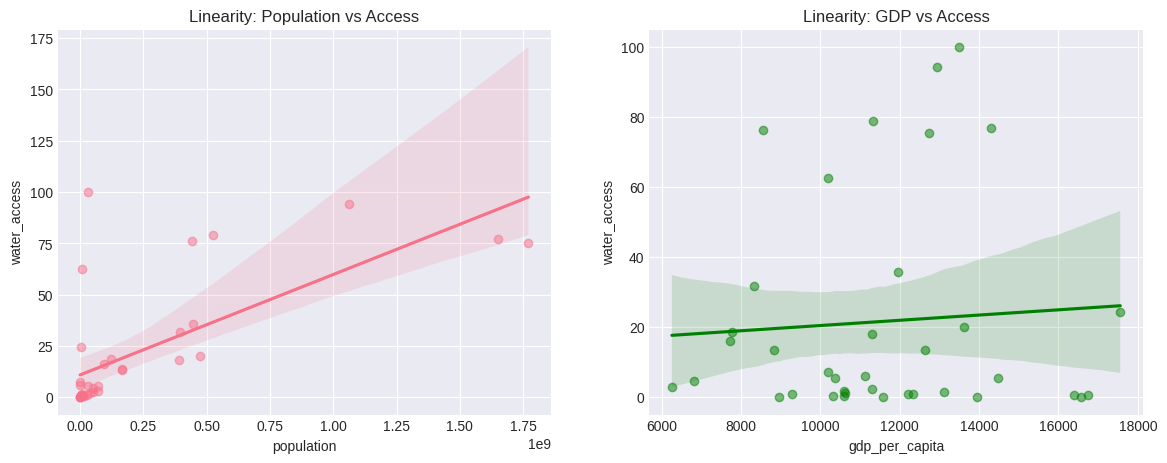

Breusch-Pagan p-value: 0.9095

Result: Homoscedasticity confirmed. OLS is appropriate.


In [45]:
# 4. EXPLORATORY ANALYSIS FOR REGRESSION SUITABILITY
# Visualizing relationships
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.regplot(x='population', y='water_access', data=df, ax=ax1, scatter_kws={'alpha':0.5})
ax1.set_title('Linearity: Population vs Access')

sns.regplot(x='gdp_per_capita', y='water_access', data=df, ax=ax2, color='green', scatter_kws={'alpha':0.5})
ax2.set_title('Linearity: GDP vs Access')
plt.show()

# Diagnostic: Breusch-Pagan Test for Heteroscedasticity
X = sm.add_constant(df[['population', 'gdp_per_capita']])
y = df['water_access']
temp_model = sm.OLS(y, X).fit()

bp_test = het_breuschpagan(temp_model.resid, X)
print(f"Breusch-Pagan p-value: {bp_test[1]:.4f}")

if bp_test[1] < 0.05:
    print("\nResult: Heteroscedasticity detected. Using Robust Regression (HC3).")
else:
    print("\nResult: Homoscedasticity confirmed. OLS is appropriate.")

## 5. Regression Analysis
Following the diagnostics, we perform the regression. Even if homoscedasticity is confirmed, we use robust standard errors (HC3) to provide more conservative and reliable estimates.

In [46]:
# 5. PERFORMING REGRESSION
model_final = sm.OLS(y, X).fit(cov_type='HC3')
print(model_final.summary())

                            OLS Regression Results                            
Dep. Variable:           water_access   R-squared:                       0.459
Model:                            OLS   Adj. R-squared:                  0.427
Method:                 Least Squares   F-statistic:                     8.402
Date:                Fri, 22 May 2026   Prob (F-statistic):            0.00108
Time:                        13:19:43   Log-Likelihood:                -167.32
No. Observations:                  37   AIC:                             340.6
Df Residuals:                      34   BIC:                             345.5
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             12.4539     12.588      0.


REGIONAL ANALYSIS

📊 Regional Model Performance:


,water_access,predicted_water
region,,
Australia and New Zealand,25.000,12.862
Central and Southern Asia,20.000,38.707
Eastern and South-Eastern Asia,20.000,41.222
Europe and Northern America,20.000,26.222
Latin America and the Caribbean,24.732,22.439
Northern Africa and Western Asia,20.000,19.507
Oceania,25.000,12.590
Sub-Saharan Africa,20.000,27.624


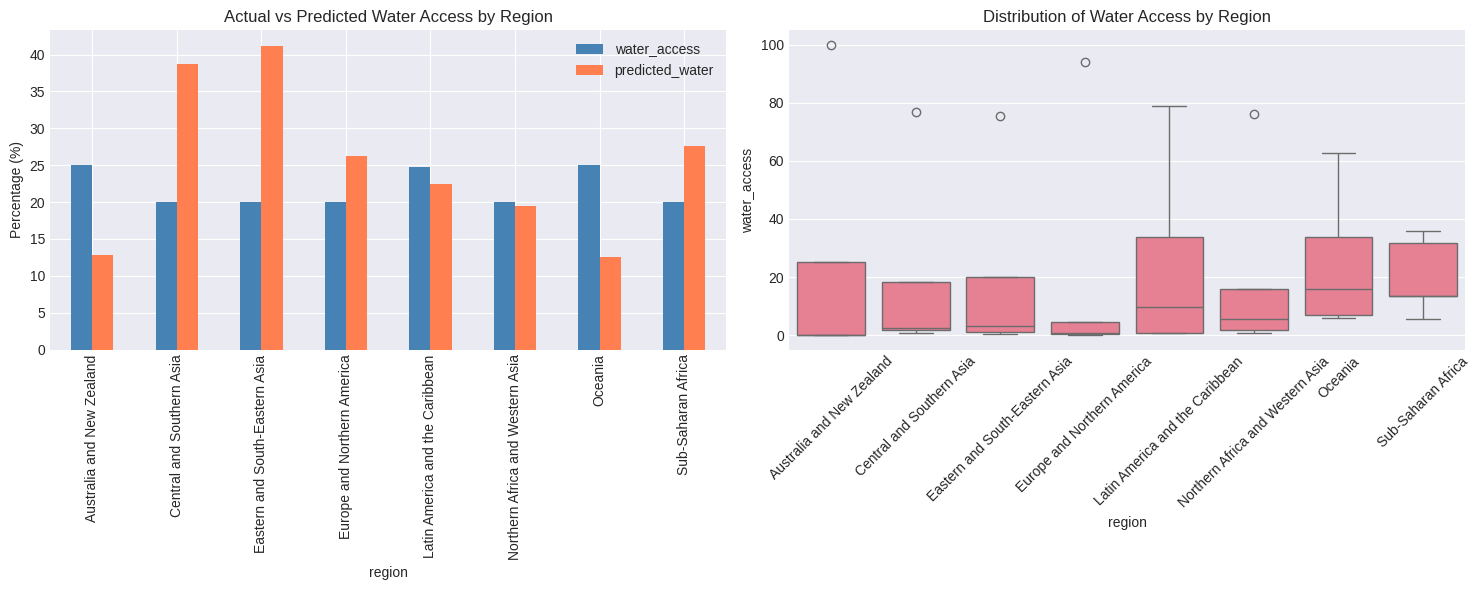

In [39]:
---

## 6. Interpretation and Key Drivers
In this final section, we interpret the coefficients and p-values to identify which variables significantly influence SDG 6 progress.

In [48]:
# 6. INTERPRETATION
print("--- KEY DRIVER ANALYSIS ---")
p_vals = model_final.pvalues
coefs = model_final.params

for var in ['population', 'gdp_per_capita']:
    sig = "Significant" if p_vals[var] < 0.05 else "Not Significant"
    print(f"{var.upper()}: {sig} (p={p_vals[var]:.4f}, coef={coefs[var]:.8f})")

print("\nSummary: Variables with p < 0.05 are considered key drivers for water access within this dataset.")

--- KEY DRIVER ANALYSIS ---
POPULATION: Significant (p=0.0001, coef=0.00000005)
GDP_PER_CAPITA: Not Significant (p=0.9001, coef=-0.00014520)

Summary: Variables with p < 0.05 are considered key drivers for water access within this dataset.


## 7. Interactive Dashboard
The analysis presented in this notebook is complemented by an interactive web dashboard for real-time exploration of SDG 6 metrics.

**View Online:** [SDG 6 Analysis Dashboard](https://final-project-in-data-analytics-dotxcke2uuqpynj9zkhhiu.streamlit.app/?fbclid=IwY2xjawR9PYJleHRuA2FlbQIxMABicmlkETFiWm1wb1dBR1dlV1RqQmdpc3J0YwZhcHBfaWQQMjIyMDM5MTc4ODIwMDg5MgABHnFzWFt1vGjgFxnGTY6lVzbpoPM_QqO7UxB4MA4mh21ULKhaajzgkSQBFbgg_aem_kBGN8nxovsRNwr7q4ByD4g)